In [1]:
#!/usr/bin/python3.10

Prerequisites: matplotlib

# Configuration

**It is assumed that this notebook is run from StructureAnalysis/sequence_analysis/tutorials**

In [2]:
import numpy as np
from openalea.sequence_analysis import Estimate
from openalea.sequence_analysis import Plot
import os
import pandas as pd
# import random
import matplotlib.pyplot as plt

Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/stat_tool/build
Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/sequence_analysis/build


#####  Place variables in markdown outputs

In [3]:
from IPython.display import Markdown
from IPython.core.magic import register_cell_magic


@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

## Loading and preparing data

In [4]:
import sys, os

In [5]:
sys.path

['/home/jdurand/usr/local/openalea',
 '/home/jdurand/miniforge3/envs/statdev/lib/python313.zip',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13/lib-dynload',
 '',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13/site-packages',
 '/home/jdurand/devlp/Git/openalea/sequence_analysis/src/openalea',
 '/home/jdurand/devlp/Git/openalea/stat_tool/src/openalea']

In [6]:
from pathlib import Path
from openalea.sequence_analysis import __path__ as seq_path
data_path = Path(seq_path[0])
data_path = str(Path.joinpath(data_path.parent.parent.parent.absolute(), "share","data"))

**Read Sequences from an existing file**

In [7]:
from openalea.sequence_analysis import (get_shared_data, 
                                        Sequences,
                                        _MarkovianSequences)
data_file = "belren1.seq"

seq = Sequences(get_shared_data(data_file))


number of sequences : 15
1  1 VARIABLE
2  
3  VARIABLE 1 : INT   # 5 values
4  
5  # value histogram - size of the sample: 1343
6  # mean: 1.30231   variance: 2.66115   standard deviation: 1.6313
7  
8  #    | value histogram
9  # 0  716         latent bud
10  # 1  153        short shoot
11  # 2  106         long shoot
12  # 3   88     fruiting shoot
13  # 4  280    immediate shoot
14  
15  # sequence length histogram - size of the sample: 15
16  # mean: 89.5333   variance: 19.4095   standard deviation: 4.40562
17  
18  # cumulative length: 1343
19  
20  2 2 2 2 1 1 1 0 0 0 1 1 1 3 3 1 1 0 1 1 1 0 1 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 1 \
21  0 0 0 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0 2 0 0 0 0 1 0 0 0 0 0 0 \
22  0 0 0 1 0 0 0 0 0
23  
24  1 1 1 0 1 3 0 1 1 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 3 0 0 0 0 0 0 0 0 0 0 \
25  0 0 0 0 0 0 0 0 0 0 0 0 2 1 2 1 2 2 0 2 1 0 2 1 1 1 1 1 0 1 0 2 0 1 2 0 0 0 0 0 0 \
26  0 0
27  
28  0 0 0 0 0 0 0 0 0 1 0 1 2 0 2 2 0 1 1 0 0 0 0 

**Print the first sequence in lines**   
`print(seq[0])` would print in a column.

In [8]:
import numpy
a0 = numpy.array(seq[0])
l0 = len(a0)
a0.resize(1,l0)
print(a0)

[[2 2 2 2 1 1 1 0 0 0 1 1 1 3 3 1 1 0 1 1 1 0 1 4 4 4 4 4 4 4 4 4 4 4 4 4
  4 4 4 4 1 0 0 0 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0 2 0
  0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]]


# TODO: elaborate on MarkovianSequences

## Exploration of Sequences

### Number of sequences

In [9]:
len(seq)

15

In [10]:
seq.nb_sequence

15

### Number of variables

In [11]:
seq.nb_variable

1

### Types of variables

# TODO: index variables from 1

In [12]:
seq.get_type(0)

0

### Identifiers of sequences (indices)

In [13]:
seq.get_identifiers()

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

### Length of a given sequence

In [14]:
seq.get_length(15)

88

Plot marginal histogram of variable 1

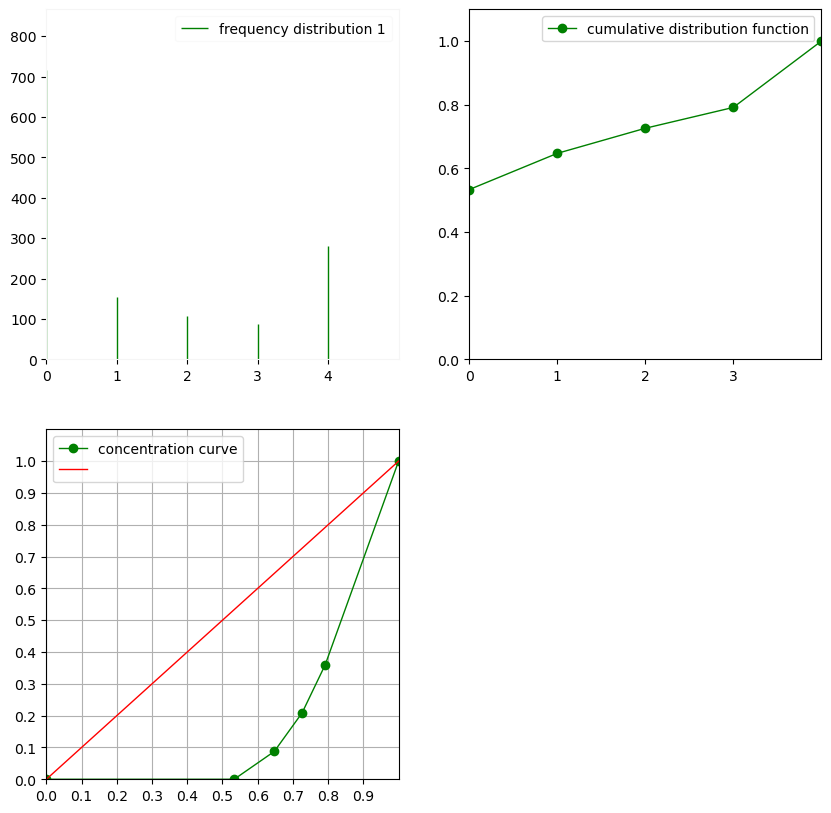

In [15]:
Plot(seq.get_marginal_histogram(1))

In [16]:
seq.get_max_value(1)

5.3801842024676e-310

## Operation on Sequences: select / reject / merge individuals or variables

### Select / reject / merge individuals

In [17]:
# Select sequence (individual) 1
seq0 = seq.select_individual([1], True)

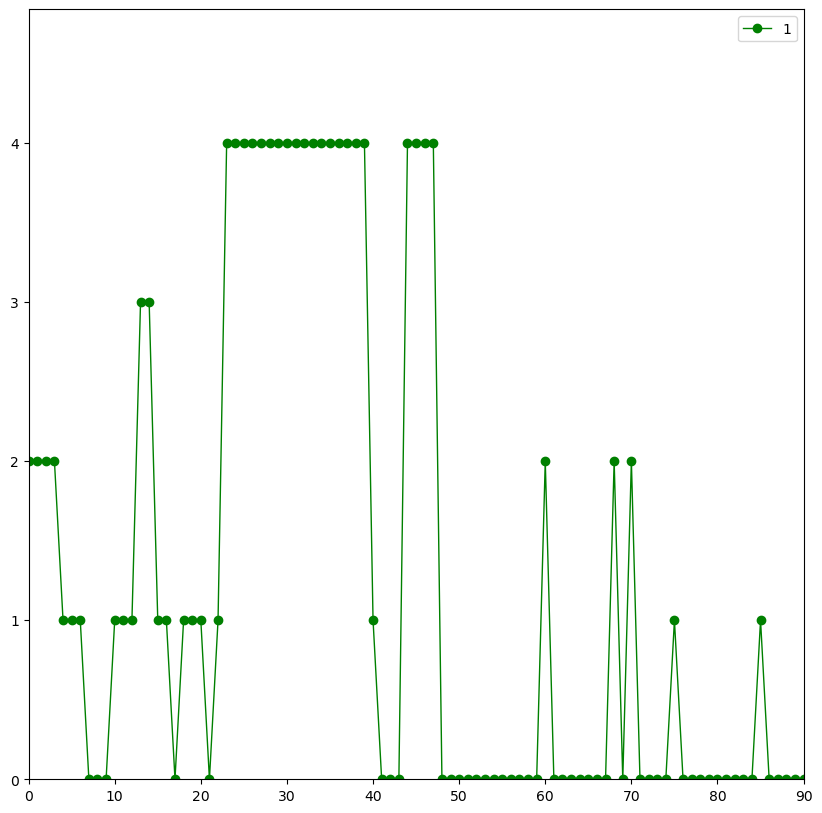

In [18]:
# Plot the sequence
Plot(seq0, ViewPoint="Data")

Note that the graph is consistent with ascii output

### Select / reject / merge variables

Duplicate sequence and shift by -1

In [19]:
seq_s1 = _MarkovianSequences(seq)
seq_s1 = _MarkovianSequences(seq_s1.shift(1,-1))

Merge seq and seq_s1

In [20]:
seq2 = seq.merge_variable([seq_s1],1)

In [21]:
print(seq2[0])

[[2, 1], [2, 1], [2, 1], [2, 1], [1, 0], [1, 0], [1, 0], [0, -1], [0, -1], [0, -1], [1, 0], [1, 0], [1, 0], [3, 2], [3, 2], [1, 0], [1, 0], [0, -1], [1, 0], [1, 0], [1, 0], [0, -1], [1, 0], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [4, 3], [1, 0], [0, -1], [0, -1], [0, -1], [4, 3], [4, 3], [4, 3], [4, 3], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [2, 1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [2, 1], [0, -1], [2, 1], [0, -1], [0, -1], [0, -1], [0, -1], [1, 0], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1], [1, 0], [0, -1], [0, -1], [0, -1], [0, -1], [0, -1]]


Select 1st variable in seq2

In [22]:
seq_v1 = seq2.select_variable([1], True)

In [23]:
seq_v1.nb_variable

1